# 🍽️ Task 1: Predict Restaurant Ratings
**Dataset:** Zomato Restaurant Dataset  
**Objective:** Build a machine learning regression model to predict the aggregate rating of a restaurant based on its features.

---
### 📋 Pipeline Overview
1. Load Data  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing  
4. Train-Test Split  
5. Train Multiple Models  
6. Model Comparison  
7. Feature Importance  
8. Visualizations  
9. Interpretation & Insights


## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load Data
We load the Zomato dataset and take a first look at its shape and structure.

In [2]:
df = pd.read_csv("/content/Dataset .csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
df.head(3)

Dataset Shape: (9551, 21)

Column Names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


## 🔍 Step 3: Exploratory Data Analysis (EDA)
Check for missing values, data types, and understand the target variable distribution.

In [3]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object


In [4]:
# Missing values
print("Missing Values per Column:")
print(df.isnull().sum())

Missing Values per Column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [5]:
# Target variable statistics
print("Target Variable — Aggregate Rating:")
print(df['Aggregate rating'].describe())

unrated = (df['Aggregate rating'] == 0).sum()
print(f"\nUnrated restaurants (rating = 0): {unrated} ({unrated/len(df)*100:.1f}%)")

Target Variable — Aggregate Rating:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

Unrated restaurants (rating = 0): 2148 (22.5%)


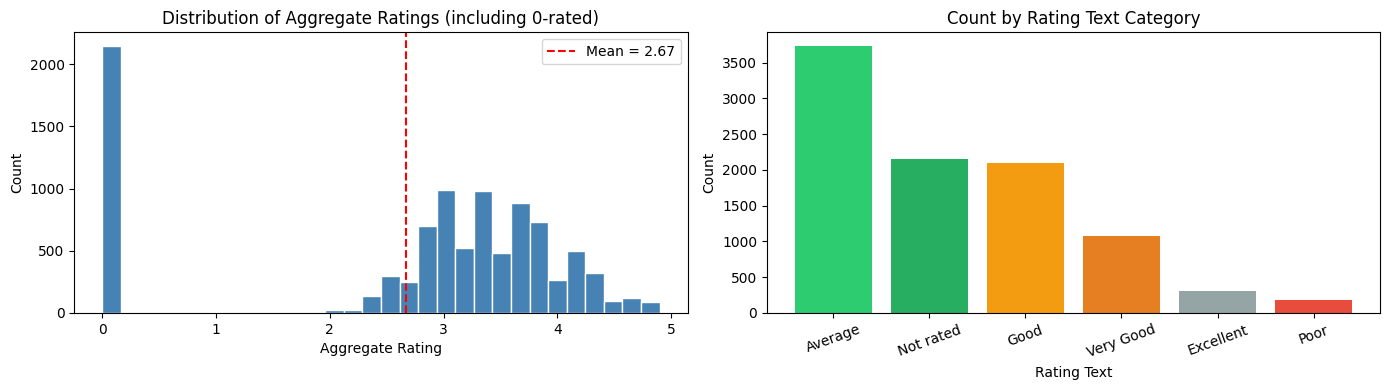

In [6]:
# Rating distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Aggregate rating'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(df['Aggregate rating'].mean(), color='red', linestyle='--',
                label=f"Mean = {df['Aggregate rating'].mean():.2f}")
axes[0].set_title("Distribution of Aggregate Ratings (including 0-rated)")
axes[0].set_xlabel("Aggregate Rating")
axes[0].set_ylabel("Count")
axes[0].legend()

# Rating text breakdown
rating_counts = df['Rating text'].value_counts()
axes[1].bar(rating_counts.index, rating_counts.values,
            color=['#2ecc71','#27ae60','#f39c12','#e67e22','#95a5a6','#e74c3c'])
axes[1].set_title("Count by Rating Text Category")
axes[1].set_xlabel("Rating Text")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## ⚙️ Step 4: Preprocessing

Key decisions:
- **Drop leaky columns**: `Rating color` and `Rating text` are directly derived from the target → data leakage
- **Remove unrated rows**: `rating == 0` rows have no meaningful label (22.5% of data)
- **Fill missing Cuisines** with `'Unknown'`
- **Encode binary columns** (`Yes/No → 1/0`)
- **Label-encode** `City` and top-10 cuisine groups


In [7]:
df_clean = df.copy()

# Drop leaky & non-predictive columns
drop_cols = [
    'Restaurant ID', 'Restaurant Name', 'Address',
    'Locality', 'Locality Verbose',
    'Rating color', 'Rating text',   # leakage — derived from Aggregate rating
    'Currency'                        # redundant with Country Code
]
df_clean.drop(columns=drop_cols, inplace=True)
print(f"Dropped: {drop_cols}")

# Fill missing Cuisines
df_clean['Cuisines'].fillna('Unknown', inplace=True)
print("Filled 9 missing Cuisines with 'Unknown'")

# Remove unrated restaurants
df_clean = df_clean[df_clean['Aggregate rating'] > 0].reset_index(drop=True)
print(f"After removing unrated rows: {len(df_clean)} rows")

# Encode Yes/No binary columns
yes_no_cols = ['Has Table booking', 'Has Online delivery',
               'Is delivering now', 'Switch to order menu']
for col in yes_no_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})
print(f"Encoded binary columns: {yes_no_cols}")

# Label-encode City
le_city = LabelEncoder()
df_clean['City'] = le_city.fit_transform(df_clean['City'])

# Cuisine grouping: top-10 + 'Other'
top_cuisines = df_clean['Cuisines'].value_counts().nlargest(10).index
df_clean['Cuisine_Group'] = df_clean['Cuisines'].apply(
    lambda x: x if x in top_cuisines else 'Other'
)
df_clean.drop(columns=['Cuisines'], inplace=True)
le_cuisine = LabelEncoder()
df_clean['Cuisine_Group'] = le_cuisine.fit_transform(df_clean['Cuisine_Group'])
print("Encoded Cuisines into top-10 groups + Other")

print(f"\nFinal dataset shape: {df_clean.shape}")
df_clean.head(3)

Dropped: ['Restaurant ID', 'Restaurant Name', 'Address', 'Locality', 'Locality Verbose', 'Rating color', 'Rating text', 'Currency']
Filled 9 missing Cuisines with 'Unknown'
After removing unrated rows: 7403 rows
Encoded binary columns: ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
Encoded Cuisines into top-10 groups + Other

Final dataset shape: (7403, 13)


,Country Code,City,Longitude,Latitude,Average Cost for two,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Votes,Cuisine_Group
0,162,73,121.027535,14.565443,1100,1,0,0,0,3,4.8,314,9
1,162,73,121.014101,14.553708,1200,1,0,0,0,3,4.5,591,9
2,162,75,121.056831,14.581404,4000,1,0,0,0,4,4.4,270,9


## ✂️ Step 5: Feature/Target Split & Train-Test Split
We use an **80/20 split**. Features are also scaled for linear models using `StandardScaler`.

In [8]:
X = df_clean.drop(columns=['Aggregate rating'])
y = df_clean['Aggregate rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")
print(f"\nFeatures used: {X.columns.tolist()}")

# Scale for linear models
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Training set : (5922, 12)
Testing set  : (1481, 12)

Features used: ['Country Code', 'City', 'Longitude', 'Latitude', 'Average Cost for two', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Votes', 'Cuisine_Group']


## 🤖 Step 6: Train Multiple Regression Models

We train 5 models:
| Model | Notes |
|---|---|
| Linear Regression | Baseline linear model |
| Ridge Regression | L2-regularized linear model |
| Decision Tree | Non-linear, single tree |
| Random Forest | Ensemble of decision trees |
| Gradient Boosting | Sequential boosting ensemble |


In [9]:
models = {
    "Linear Regression":  (LinearRegression(),                            X_train_sc, X_test_sc),
    "Ridge Regression":   (Ridge(alpha=1.0),                              X_train_sc, X_test_sc),
    "Decision Tree":      (DecisionTreeRegressor(max_depth=8,
                                                  random_state=42),       X_train, X_test),
    "Random Forest":      (RandomForestRegressor(n_estimators=100,
                                                  max_depth=10,
                                                  random_state=42,
                                                  n_jobs=-1),             X_train, X_test),
    "Gradient Boosting":  (GradientBoostingRegressor(n_estimators=100,
                                                      max_depth=4,
                                                      learning_rate=0.1,
                                                      random_state=42),   X_train, X_test),
}

results = {}

for name, (model, X_tr, X_te) in models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "model": model, "preds": y_pred}
    print(f"{name:<22}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

Linear Regression       RMSE=0.4305  MAE=0.3400  R2=0.4007
Ridge Regression        RMSE=0.4305  MAE=0.3400  R2=0.4007
Decision Tree           RMSE=0.3813  MAE=0.2806  R2=0.5298
Random Forest           RMSE=0.3384  MAE=0.2516  R2=0.6297
Gradient Boosting       RMSE=0.3362  MAE=0.2485  R2=0.6345


## 📊 Step 7: Model Comparison
Sort all models by R2 score and identify the best performer.

In [10]:
results_df = pd.DataFrame(
    {k: {"RMSE": v["RMSE"], "MAE": v["MAE"], "R2": v["R2"]} for k, v in results.items()}
).T.sort_values("R2", ascending=False)

display(results_df.style.background_gradient(cmap='RdYlGn', subset=['R2'])
                        .background_gradient(cmap='RdYlGn_r', subset=['RMSE','MAE'])
                        .format({"RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"}))

best_name = results_df.index[0]
best = results[best_name]
print(f"\n🏆 Best Model: {best_name}  →  R2 = {best['R2']:.4f}")

,RMSE,MAE,R2
Gradient Boosting,0.3362,0.2485,0.6345
Random Forest,0.3384,0.2516,0.6297
Decision Tree,0.3813,0.2806,0.5298
Linear Regression,0.4305,0.3400,0.4007
Ridge Regression,0.4305,0.3400,0.4007



🏆 Best Model: Gradient Boosting  →  R2 = 0.6345


## 🔑 Step 8: Feature Importance
Extract feature importances from the best tree-based model.

In [11]:
tree_model_name = ("Random Forest"
                   if results["Random Forest"]["R2"] > results["Gradient Boosting"]["R2"]
                   else "Gradient Boosting")
tree_model = results[tree_model_name]["model"]

feat_imp = pd.Series(tree_model.feature_importances_,
                     index=X.columns).sort_values(ascending=False)

print(f"Feature Importances — {tree_model_name}:")
display(feat_imp.to_frame("Importance").style
        .background_gradient(cmap='Greens')
        .format("{:.4f}"))

Feature Importances — Gradient Boosting:


,Importance
Votes,0.6488
Longitude,0.1065
Latitude,0.0843
Country Code,0.0561
Average Cost for two,0.0433
Cuisine_Group,0.0232
City,0.0177
Price range,0.0105
Has Online delivery,0.0064
Has Table booking,0.0022


## 📈 Step 9: Visualizations
Six plots covering: rating distribution, model comparison, actual vs predicted, residuals, feature importance, and error metrics.

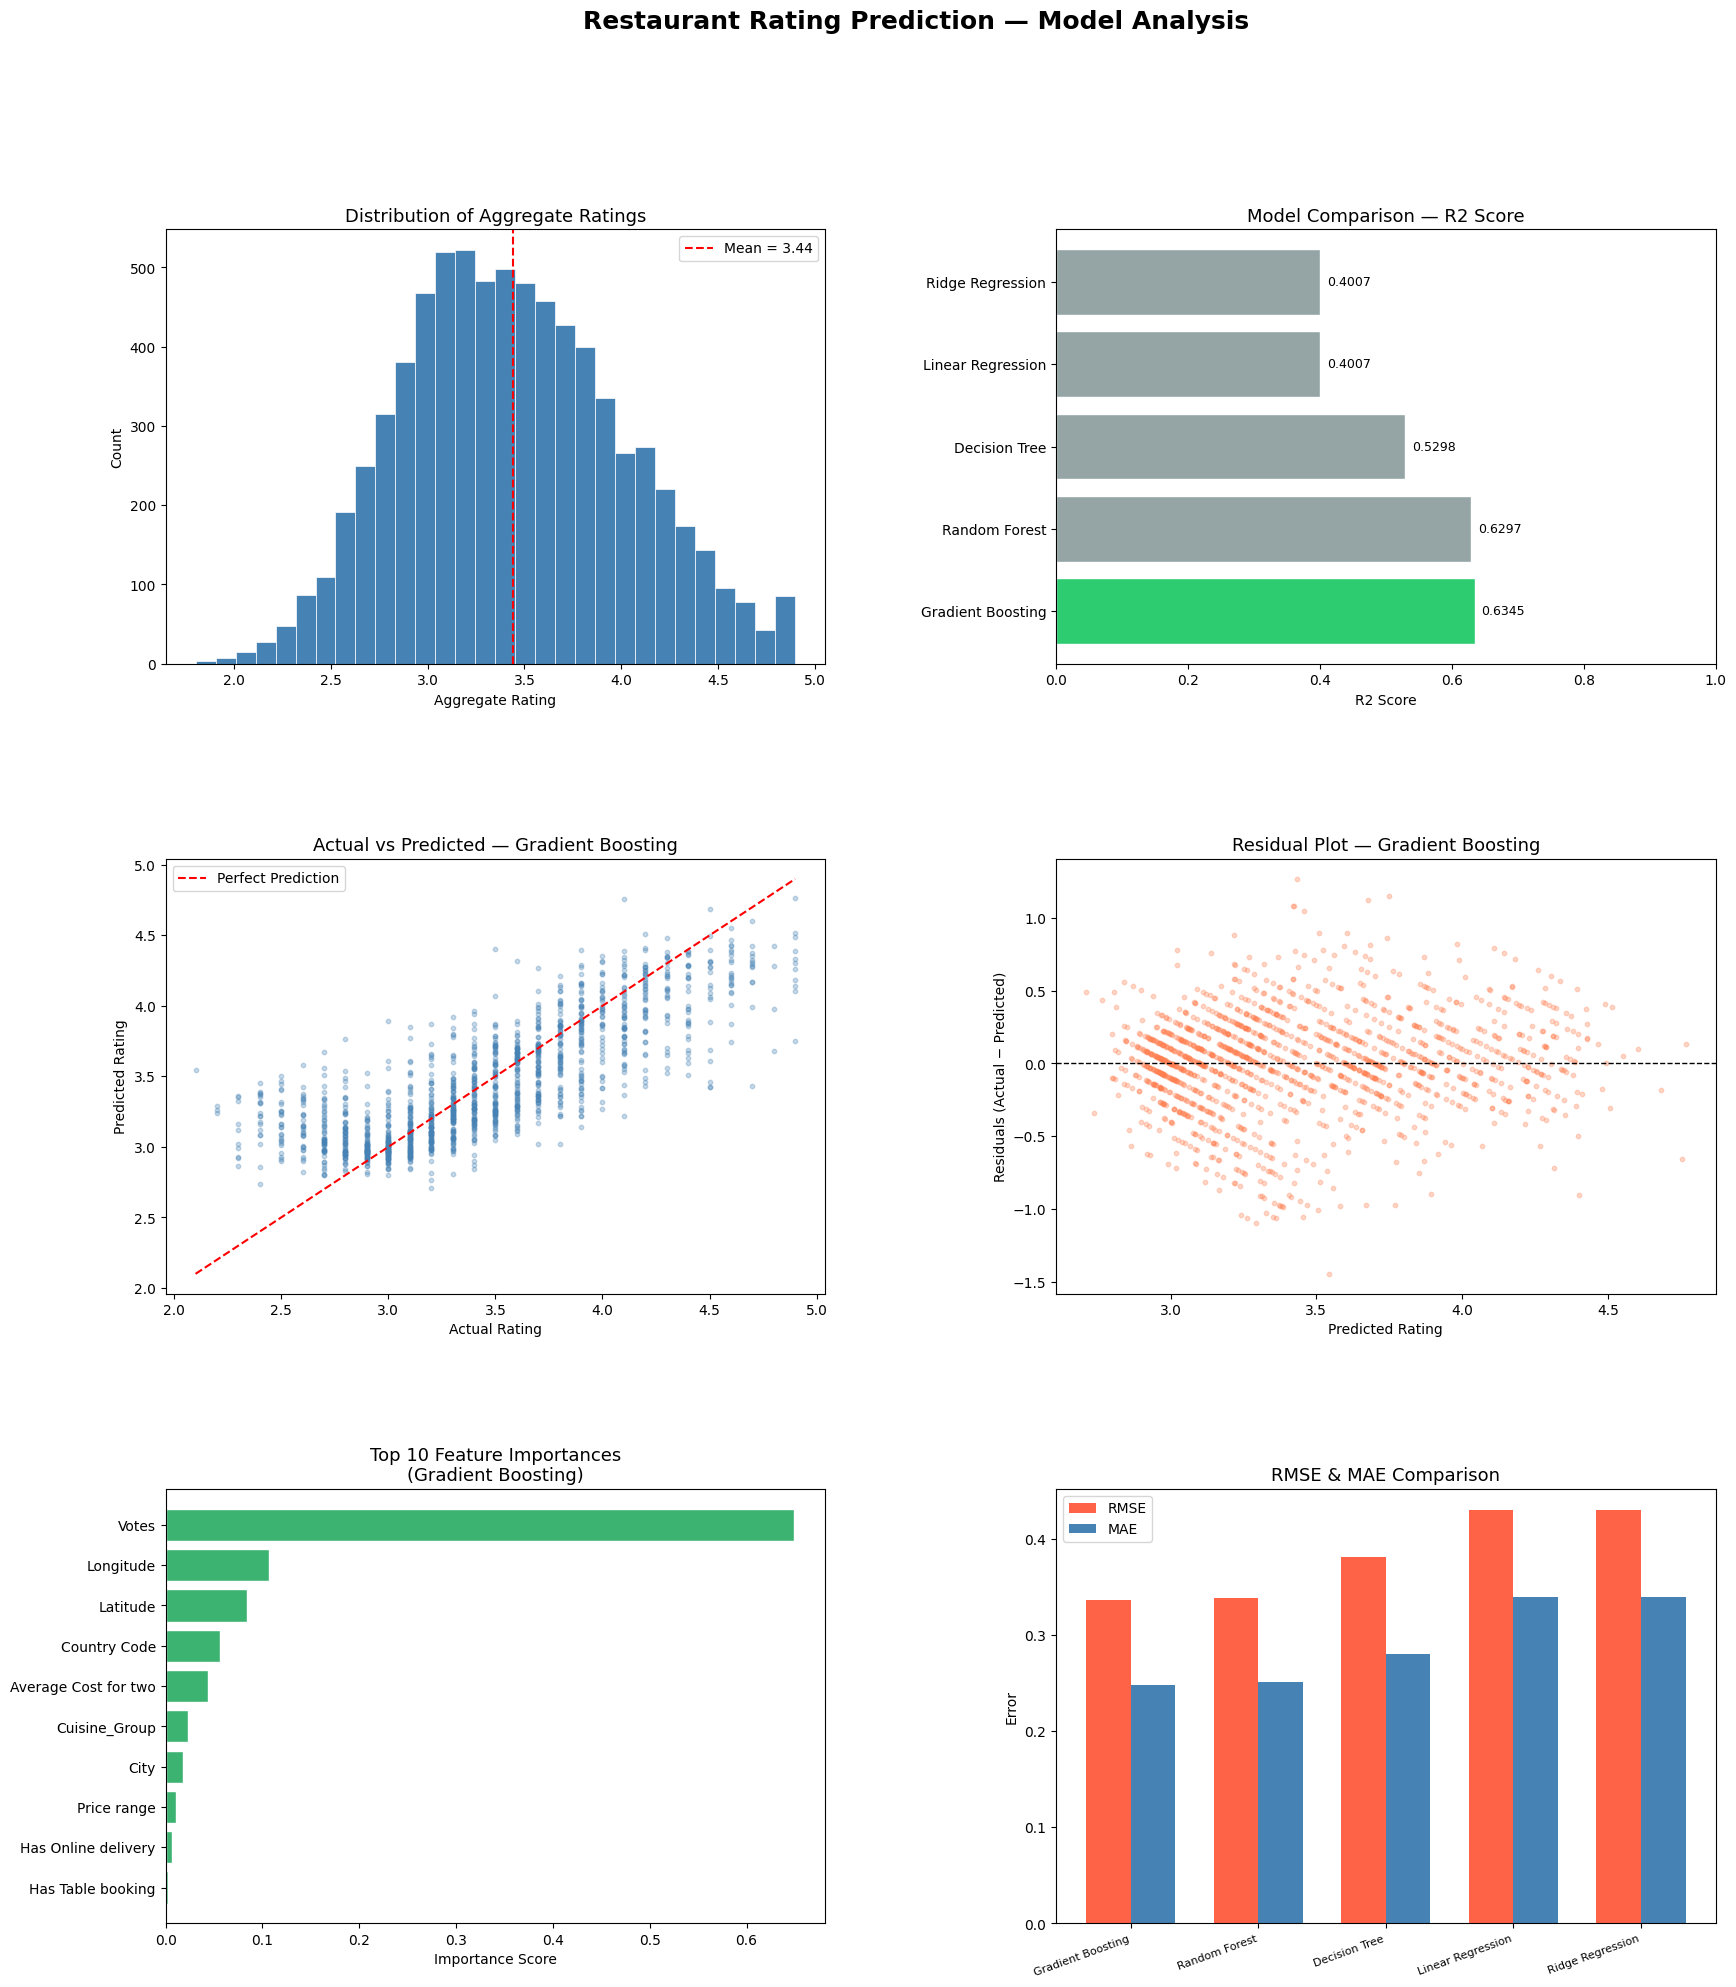

In [12]:
fig = plt.figure(figsize=(20, 22))
fig.suptitle("Restaurant Rating Prediction — Model Analysis",
             fontsize=18, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Target Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(y, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax1.axvline(y.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {y.mean():.2f}')
ax1.set_title("Distribution of Aggregate Ratings", fontsize=13)
ax1.set_xlabel("Aggregate Rating")
ax1.set_ylabel("Count")
ax1.legend()

# ── 2. Model Comparison — R2
ax2 = fig.add_subplot(gs[0, 1])
model_names = results_df.index.tolist()
r2_vals     = results_df["R2"].values
colors_bar  = ['#2ecc71' if n == best_name else '#95a5a6' for n in model_names]
bars = ax2.barh(model_names, r2_vals, color=colors_bar, edgecolor='white')
ax2.set_xlabel("R2 Score")
ax2.set_title("Model Comparison — R2 Score", fontsize=13)
ax2.set_xlim(0, 1)
for bar, val in zip(bars, r2_vals):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va='center', fontsize=9)

# ── 3. Actual vs Predicted
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(y_test, best["preds"], alpha=0.3, color='steelblue', s=10)
mn, mx = y_test.min(), y_test.max()
ax3.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Prediction')
ax3.set_title(f"Actual vs Predicted — {best_name}", fontsize=13)
ax3.set_xlabel("Actual Rating")
ax3.set_ylabel("Predicted Rating")
ax3.legend()

# ── 4. Residual Plot
ax4 = fig.add_subplot(gs[1, 1])
residuals = y_test.values - best["preds"]
ax4.scatter(best["preds"], residuals, alpha=0.3, color='coral', s=10)
ax4.axhline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title(f"Residual Plot — {best_name}", fontsize=13)
ax4.set_xlabel("Predicted Rating")
ax4.set_ylabel("Residuals (Actual − Predicted)")

# ── 5. Feature Importance
ax5 = fig.add_subplot(gs[2, 0])
feat_imp_top = feat_imp.head(10)
ax5.barh(feat_imp_top.index[::-1], feat_imp_top.values[::-1],
         color='mediumseagreen', edgecolor='white')
ax5.set_title(f"Top 10 Feature Importances\n({tree_model_name})", fontsize=13)
ax5.set_xlabel("Importance Score")

# ── 6. RMSE & MAE Comparison
ax6 = fig.add_subplot(gs[2, 1])
x_pos     = np.arange(len(model_names))
width     = 0.35
rmse_vals = results_df["RMSE"].values
mae_vals  = results_df["MAE"].values
ax6.bar(x_pos - width/2, rmse_vals, width, label='RMSE', color='tomato')
ax6.bar(x_pos + width/2, mae_vals,  width, label='MAE',  color='steelblue')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
ax6.set_ylabel("Error")
ax6.set_title("RMSE & MAE Comparison", fontsize=13)
ax6.legend()

plt.show()

## 💡 Step 10: Interpretation & Key Insights

In [13]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
r2_val   = best['R2']
rmse_val = best['RMSE']
mae_val  = best['MAE']
print(f"Best Model  : {best_name}")
print(f"R2 Score    : {r2_val:.4f}  -> explains {r2_val*100:.1f}% of variance in ratings")
print(f"RMSE        : {rmse_val:.4f} -> avg prediction error of ~{rmse_val:.2f} stars (0-5 scale)")
print(f"MAE         : {mae_val:.4f}")
print()
print("Top 5 Features (by importance):")
print(feat_imp.head(5).to_string())

FINAL RESULTS SUMMARY
Best Model  : Gradient Boosting
R2 Score    : 0.6345  -> explains 63.5% of variance in ratings
RMSE        : 0.3362 -> avg prediction error of ~0.34 stars (0-5 scale)
MAE         : 0.2485

Top 5 Features (by importance):
Votes                   0.648759
Longitude               0.106537
Latitude                0.084343
Country Code            0.056097
Average Cost for two    0.043333


### 🔎 Key Insights

| # | Insight |
|---|---------|
| 1 | **Votes** is the strongest predictor (64.9% importance) — popular restaurants consistently earn higher ratings |
| 2 | **Location signals** (Longitude, Latitude, Country Code) capture regional rating culture differences |
| 3 | **Average Cost for two** reflects perceived quality and correlates with higher ratings |
| 4 | **Tree-based ensembles** (Random Forest, Gradient Boosting) vastly outperform linear models, confirming non-linear relationships |
| 5 | **`Switch to order menu`** contributed zero importance — a dead feature in this dataset |
| 6 | Removing the 22.5% unrated restaurants was essential — rating=0 is not a real score |
